Device: cuda
Initial symbol: ^SPX


Fetching Yahoo option chains for ^SPX:   0%|          | 0/55 [00:00<?, ?it/s]

Final symbol: ^SPX
Spot S0: 7230.1201171875
Raw option chain shape: (12003, 20)


Solving BS IV:   0%|          | 0/6139 [00:00<?, ?it/s]

OTM IV points: (6139, 24)
       expiry option_type       K         k         T    mid        iv
0  2026-05-26         put  5400.0 -0.291857  0.060274  0.950  0.456906
1  2026-05-26         put  5600.0 -0.255489  0.060274  1.300  0.419731
2  2026-05-26         put  5700.0 -0.237789  0.060274  1.550  0.401921
3  2026-05-26         put  5800.0 -0.220398  0.060274  1.825  0.383364
4  2026-05-26         put  5900.0 -0.203303  0.060274  2.150  0.364648
count    6139.000000
mean        0.209806
std         0.065817
min         0.049154
25%         0.154179
50%         0.202144
75%         0.253461
max         0.456906
Name: iv, dtype: float64
Base surface shape: (41, 20)
Base surface min/max: 0.111766286 0.45690602


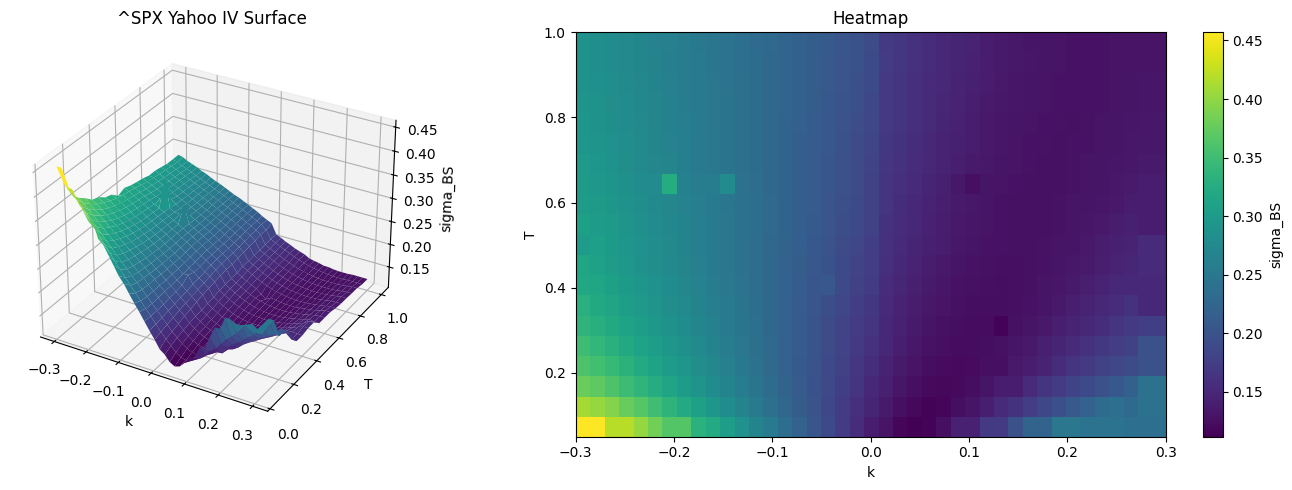

Synthetic surfaces shape: (250, 41, 20)


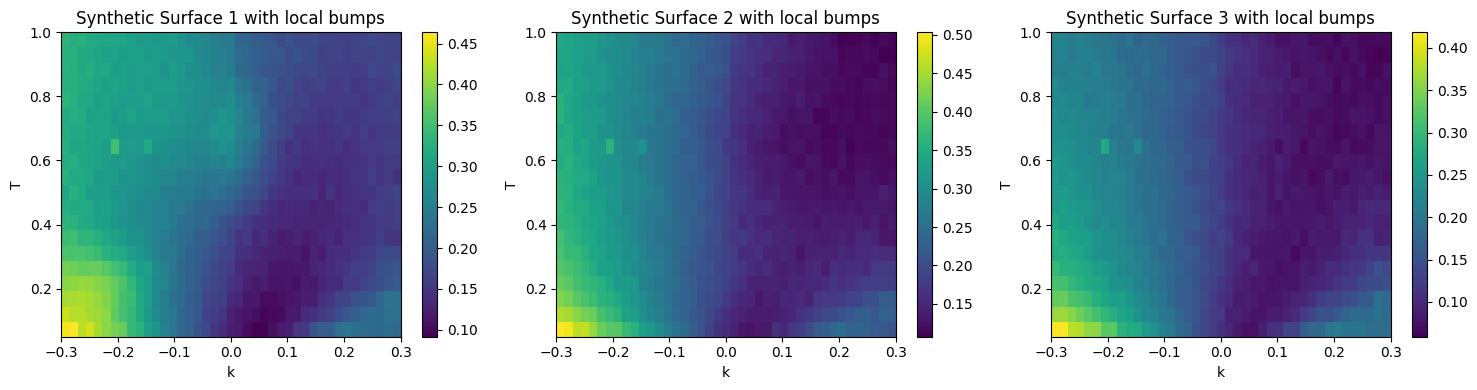

Sanity check local-vol-style Asian price: 142.2264281384457


Generating local-vol MC labels:   0%|          | 0/250 [00:00<?, ?it/s]

X_surface: (5000, 41, 20)
X_contract [k,T,single_iv]: (5000, 3)
y: (5000, 1)
count    5000.000000
mean      569.689392
std       637.358093
min         0.000000
25%         1.043239
50%       264.237244
75%      1121.142456
max      1977.628296
dtype: float64
Train samples: 3750
Test samples: 1250


Training VAE-style compressor:   0%|          | 0/300 [00:00<?, ?it/s]

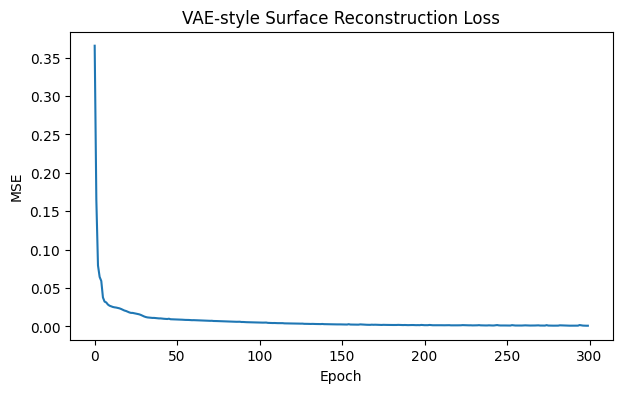

Z_train: (3750, 10)
Z_test: (1250, 10)


Training MLP:   0%|          | 0/300 [00:00<?, ?it/s]

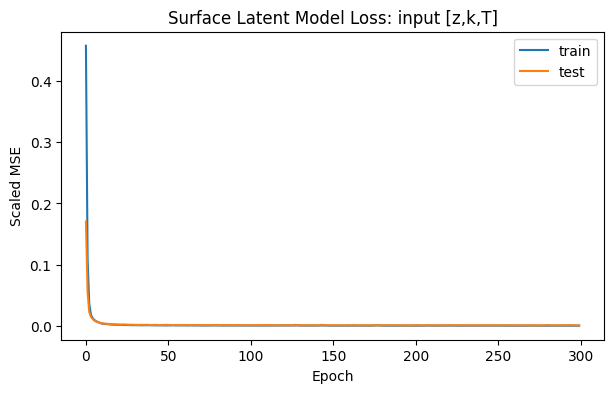

Training MLP:   0%|          | 0/300 [00:00<?, ?it/s]

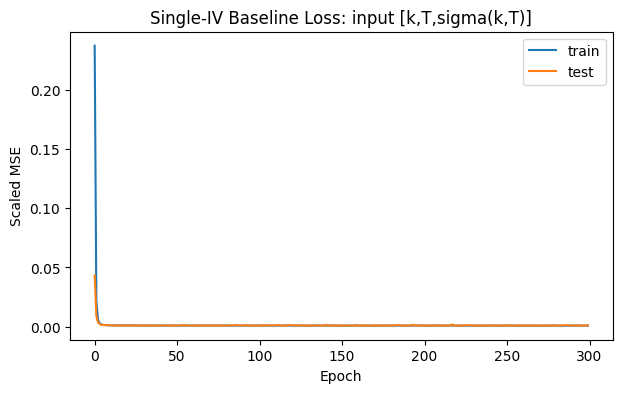

,Model,MAE,RMSE,MAPE
0,"Surface latent [z,k,T]",13.151533,18.518440,87752904.0
1,"Single IV [k,T,iv]",14.950922,21.882965,36968640.0


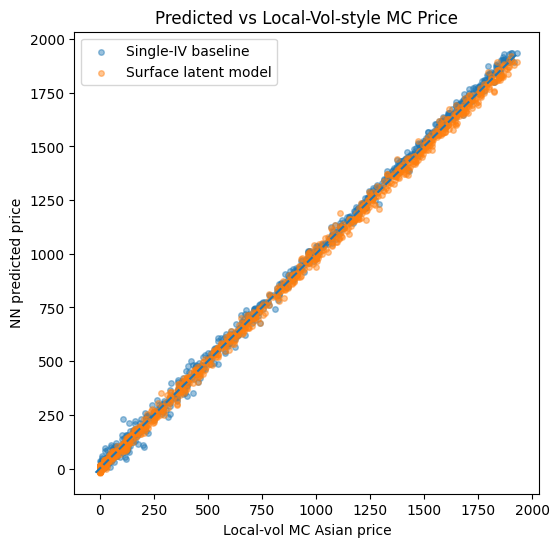

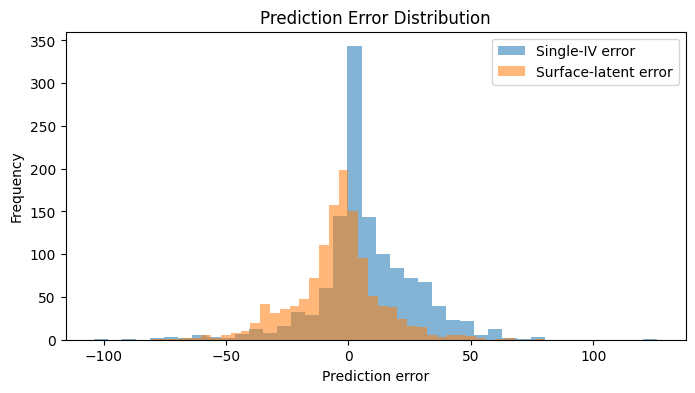

Saved outputs to: local_vol_surface_pricing_experiment

Numerical experiment summary:

I first constructed an implied volatility surface from Yahoo Finance option-chain data.
For each strike and maturity, I selected the out-of-the-money side of the option chain
and solved the Black-Scholes implied volatility from the bid-ask mid price. The irregular
option-chain data were transformed into log-moneyness k = log(K/S0) and interpolated onto
a fixed 41 x 20 grid over k and maturity T.

To test whether a full volatility surface contains useful information beyond a single
implied volatility point, I generated synthetic surface regimes and then priced arithmetic
Asian options using a local-volatility-style Monte Carlo simulation. In this simulation,
the path volatility at each time step is obtained from the full surface according to
sigma_u = sigma_surface(log(S_u/S0), u). Therefore, the label depends on the broader
shape of the volatility surface rather than only on sigma(k,T).

I then compa

In [ ]:
# ============================================================
# Yahoo IV Surface -> Local-Vol-style MC Labels -> VAE-style Encoder + MLP Pricer
#
# Goal:
#   Fix the previous issue where QuantLib label only depended on single IV sigma(k,T).
#
# New label construction:
#   dS_u = (r - q) S_u du + sigma_loc(S_u, u) S_u dW_u
#
# Here we approximate:
#   sigma_loc(S_u, u) ~= interpolated surface value at
#   k_u = log(S_u / S0), maturity/time u
#
# Important:
#   This is a local-vol-style numerical experiment.
#   It is NOT an exact Dupire local volatility implementation.
#
# Pipeline:
#   1. Download Yahoo option chain for ^SPX or SPY
#   2. Build OTM IV surface sigma_BS(k,T)
#   3. Generate synthetic surface regimes
#   4. Generate Asian option labels using local-vol-style MC
#   5. Train VAE-style surface compressor
#   6. Train MLP pricer with [z, k, T]
#   7. Compare against single-IV baseline [k, T, sigma(k,T)]
# ============================================================


# ============================================================
# 1. Imports
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.optimize import brentq
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# ============================================================
# 2. Config
# ============================================================

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

SYMBOL = "^SPX"       # If ^SPX fails, code will switch to SPY
RISK_FREE_RATE = 0.04
DIVIDEND_YIELD = 0.00

# Paper-style grid
K_MIN, K_MAX = -0.30, 0.30
T_MIN, T_MAX = 0.05, 1.00

N_K = 41
N_T = 20

k_grid = np.linspace(K_MIN, K_MAX, N_K)
T_grid = np.linspace(T_MIN, T_MAX, N_T)

# Synthetic experiment size
N_SYN_SURFACES = 250
N_OPTIONS_PER_SURFACE = 20

# Local-vol MC settings
N_MC_PATHS = 800
N_MC_STEPS = 32
OPTION_TYPE = "call"   # "call" or "put" for Asian option label

# Model settings
LATENT_DIM = 10
BATCH_SIZE = 128
VAE_EPOCHS = 300
MLP_EPOCHS = 300
LR = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OUTPUT_DIR = Path("local_vol_surface_pricing_experiment")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Device:", device)
print("Initial symbol:", SYMBOL)


# ============================================================
# 3. Black-Scholes helpers for IV solving
# ============================================================

def bs_price(S, K, T, r, q, sigma, option_type):
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return np.nan

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

    if option_type == "put":
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)

    raise ValueError("option_type must be 'call' or 'put'")


def implied_vol_from_mid(mid, S, K, T, r, q, option_type):
    if not np.isfinite(mid) or mid <= 0 or T <= 0 or S <= 0 or K <= 0:
        return np.nan

    def objective(sig):
        return bs_price(S, K, T, r, q, sig, option_type) - mid

    try:
        return brentq(objective, 1e-6, 5.0, maxiter=200)
    except Exception:
        return np.nan


# ============================================================
# 4. Fetch Yahoo option chain
# ============================================================

def fetch_yahoo_chain(symbol):
    tk = yf.Ticker(symbol)

    hist = tk.history(period="10d")
    if hist.empty:
        raise RuntimeError(f"Cannot fetch spot price for {symbol}")

    S0 = float(hist["Close"].dropna().iloc[-1])
    expiries = list(tk.options)

    if len(expiries) == 0:
        raise RuntimeError(f"No option expiries found for {symbol}")

    today = pd.Timestamp.today(tz=None).normalize()
    rows = []

    for exp in tqdm(expiries, desc=f"Fetching Yahoo option chains for {symbol}"):
        exp_date = pd.Timestamp(exp)
        T = (exp_date - today).days / 365.0

        if T < T_MIN or T > T_MAX:
            continue

        try:
            chain = tk.option_chain(exp)
        except Exception:
            continue

        calls = chain.calls.copy()
        puts = chain.puts.copy()

        calls["option_type"] = "call"
        puts["option_type"] = "put"

        df = pd.concat([calls, puts], ignore_index=True)
        df["expiry"] = exp
        df["T"] = T
        df["S0"] = S0
        df["K"] = pd.to_numeric(df["strike"], errors="coerce")
        df["k"] = np.log(df["K"] / S0)

        rows.append(df)

    if len(rows) == 0:
        raise RuntimeError("No valid option chain in selected maturity range.")

    raw = pd.concat(rows, ignore_index=True)
    return S0, raw


try:
    S0, raw_chain = fetch_yahoo_chain(SYMBOL)
except Exception as e:
    print("Failed with ^SPX:", e)
    print("Switching to SPY.")
    SYMBOL = "SPY"
    S0, raw_chain = fetch_yahoo_chain(SYMBOL)

print("Final symbol:", SYMBOL)
print("Spot S0:", S0)
print("Raw option chain shape:", raw_chain.shape)
raw_chain.head()


# ============================================================
# 5. Select OTM options and solve BS IV
# ============================================================

def prepare_otm_iv_points(raw_chain, S0):
    df = raw_chain.copy()

    for col in ["bid", "ask", "lastPrice", "impliedVolatility", "K", "T", "k"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["mid"] = (df["bid"] + df["ask"]) / 2.0

    bad_mid = (~np.isfinite(df["mid"])) | (df["mid"] <= 0)
    df.loc[bad_mid, "mid"] = df.loc[bad_mid, "lastPrice"]

    df["yahoo_iv"] = df["impliedVolatility"]

    # Paper-style OTM rule:
    # K < S0 -> use OTM put
    # K > S0 -> use OTM call
    otm_puts = df[(df["option_type"] == "put") & (df["K"] < S0)].copy()
    otm_calls = df[(df["option_type"] == "call") & (df["K"] > S0)].copy()

    otm = pd.concat([otm_puts, otm_calls], ignore_index=True)

    otm = otm[
        (otm["k"] >= K_MIN) &
        (otm["k"] <= K_MAX) &
        (otm["T"] >= T_MIN) &
        (otm["T"] <= T_MAX) &
        (otm["mid"] > 0) &
        np.isfinite(otm["mid"])
    ].copy()

    if otm.empty:
        raise RuntimeError("No OTM options left after filtering. Try SPY or loosen ranges.")

    solved = []

    for row in tqdm(otm.itertuples(index=False), total=len(otm), desc="Solving BS IV"):
        iv = implied_vol_from_mid(
            mid=row.mid,
            S=row.S0,
            K=row.K,
            T=row.T,
            r=RISK_FREE_RATE,
            q=DIVIDEND_YIELD,
            option_type=row.option_type
        )
        solved.append(iv)

    otm["bs_iv_solved"] = solved
    otm["iv"] = otm["bs_iv_solved"]

    # fallback to Yahoo IV
    fallback = (~np.isfinite(otm["iv"])) | (otm["iv"] <= 0)
    otm.loc[fallback, "iv"] = otm.loc[fallback, "yahoo_iv"]

    otm = otm[
        np.isfinite(otm["iv"]) &
        (otm["iv"] > 0.01) &
        (otm["iv"] < 3.00)
    ].copy()

    otm = otm.sort_values(["T", "K"]).reset_index(drop=True)

    return otm


iv_points = prepare_otm_iv_points(raw_chain, S0)

print("OTM IV points:", iv_points.shape)
print(iv_points[["expiry", "option_type", "K", "k", "T", "mid", "iv"]].head())
print(iv_points["iv"].describe())


# ============================================================
# 6. Interpolate to fixed IV surface grid
# ============================================================

def interpolate_iv_surface(iv_points, k_grid, T_grid):
    points = iv_points[["k", "T"]].values
    values = iv_points["iv"].values

    linear_interp = LinearNDInterpolator(points, values)
    nearest_interp = NearestNDInterpolator(points, values)

    K_mesh, T_mesh = np.meshgrid(k_grid, T_grid, indexing="ij")
    query = np.column_stack([K_mesh.ravel(), T_mesh.ravel()])

    surf_linear = linear_interp(query).reshape(len(k_grid), len(T_grid))
    surf_nearest = nearest_interp(query).reshape(len(k_grid), len(T_grid))

    surface = np.where(np.isnan(surf_linear), surf_nearest, surf_linear)
    surface = np.clip(surface, 0.01, 3.00)

    return surface.astype(np.float32)


base_surface = interpolate_iv_surface(iv_points, k_grid, T_grid)

print("Base surface shape:", base_surface.shape)
print("Base surface min/max:", base_surface.min(), base_surface.max())

K_mesh, T_mesh = np.meshgrid(k_grid, T_grid, indexing="ij")

fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(K_mesh, T_mesh, base_surface, cmap="viridis", linewidth=0)
ax1.set_xlabel("k")
ax1.set_ylabel("T")
ax1.set_zlabel("sigma_BS")
ax1.set_title(f"{SYMBOL} Yahoo IV Surface")

ax2 = fig.add_subplot(1, 2, 2)
im = ax2.imshow(
    base_surface.T,
    origin="lower",
    aspect="auto",
    extent=[K_MIN, K_MAX, T_MIN, T_MAX],
    cmap="viridis"
)
ax2.set_xlabel("k")
ax2.set_ylabel("T")
ax2.set_title("Heatmap")
fig.colorbar(im, ax=ax2, label="sigma_BS")

plt.tight_layout()
plt.show()


# ============================================================
# 7. Generate synthetic volatility surfaces
#    Add local bumps so the full surface contains information
#    that a single IV point may not capture.
# ============================================================

def augment_surface(base_surface):
    K_mesh, T_mesh = np.meshgrid(k_grid, T_grid, indexing="ij")

    # Smooth global factors
    level = np.random.normal(0.0, 0.025)
    skew = np.random.normal(0.0, 0.08)
    curvature = np.random.normal(0.0, 0.06)
    term = np.random.normal(0.0, 0.04)
    twist = np.random.normal(0.0, 0.03)
    noise = np.random.normal(0.0, 0.004, size=base_surface.shape)

    global_perturb = (
        level
        + skew * K_mesh
        + curvature * (K_mesh**2 - np.mean(k_grid**2))
        + term * (T_mesh - np.mean(T_grid))
        + twist * K_mesh * (T_mesh - np.mean(T_grid))
        + noise
    )

    # ------------------------------------------------------------
    # Local bumps:
    # These create localized smile/term-structure distortions.
    # This makes the label more dependent on the full surface shape.
    # ------------------------------------------------------------
    n_bumps = np.random.randint(1, 4)  # 1 to 3 bumps per surface
    local_bump = np.zeros_like(base_surface, dtype=np.float32)

    for _ in range(n_bumps):
        bump_k = np.random.uniform(-0.25, 0.25)
        bump_T = np.random.uniform(0.10, 0.90)
        bump_amp = np.random.normal(0.0, 0.05)
        bump_width_k = np.random.uniform(0.04, 0.10)
        bump_width_T = np.random.uniform(0.08, 0.20)

        bump = bump_amp * np.exp(
            -0.5 * ((K_mesh - bump_k) / bump_width_k) ** 2
            -0.5 * ((T_mesh - bump_T) / bump_width_T) ** 2
        )

        local_bump += bump.astype(np.float32)

    surface = base_surface + global_perturb + local_bump

    # Keep IV in a realistic range
    surface = np.clip(surface, 0.05, 1.50)

    return surface.astype(np.float32)


surfaces = np.stack(
    [augment_surface(base_surface) for _ in range(N_SYN_SURFACES)],
    axis=0
)

print("Synthetic surfaces shape:", surfaces.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, ax in enumerate(axes):
    im = ax.imshow(
        surfaces[i].T,
        origin="lower",
        aspect="auto",
        extent=[K_MIN, K_MAX, T_MIN, T_MAX],
        cmap="viridis"
    )
    ax.set_title(f"Synthetic Surface {i+1} with local bumps")
    ax.set_xlabel("k")
    ax.set_ylabel("T")
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


# ============================================================
# 8. Fast bilinear interpolation from surface
# ============================================================

def bilinear_surface_iv_scalar(surface, k, T):
    """
    Scalar bilinear interpolation on fixed grid.
    """
    k = float(np.clip(k, k_grid[0], k_grid[-1]))
    T = float(np.clip(T, T_grid[0], T_grid[-1]))

    i = np.searchsorted(k_grid, k) - 1
    j = np.searchsorted(T_grid, T) - 1

    i = int(np.clip(i, 0, len(k_grid) - 2))
    j = int(np.clip(j, 0, len(T_grid) - 2))

    k0, k1 = k_grid[i], k_grid[i + 1]
    T0, T1 = T_grid[j], T_grid[j + 1]

    q00 = surface[i, j]
    q10 = surface[i + 1, j]
    q01 = surface[i, j + 1]
    q11 = surface[i + 1, j + 1]

    wk = (k - k0) / (k1 - k0 + 1e-12)
    wT = (T - T0) / (T1 - T0 + 1e-12)

    val = (
        (1 - wk) * (1 - wT) * q00
        + wk * (1 - wT) * q10
        + (1 - wk) * wT * q01
        + wk * wT * q11
    )

    return float(val)


def bilinear_surface_iv_vectorized(surface, k_values, T_value):
    """
    Vectorized bilinear interpolation for many k_values at the same T_value.
    This is used inside MC.
    """
    k_values = np.asarray(k_values, dtype=np.float64)
    k_values = np.clip(k_values, k_grid[0], k_grid[-1])
    T_value = float(np.clip(T_value, T_grid[0], T_grid[-1]))

    i = np.searchsorted(k_grid, k_values) - 1
    j = np.searchsorted(T_grid, T_value) - 1

    i = np.clip(i, 0, len(k_grid) - 2).astype(int)
    j = int(np.clip(j, 0, len(T_grid) - 2))

    k0 = k_grid[i]
    k1 = k_grid[i + 1]
    T0 = T_grid[j]
    T1 = T_grid[j + 1]

    q00 = surface[i, j]
    q10 = surface[i + 1, j]
    q01 = surface[i, j + 1]
    q11 = surface[i + 1, j + 1]

    wk = (k_values - k0) / (k1 - k0 + 1e-12)
    wT = (T_value - T0) / (T1 - T0 + 1e-12)

    vals = (
        (1 - wk) * (1 - wT) * q00
        + wk * (1 - wT) * q10
        + (1 - wk) * wT * q01
        + wk * wT * q11
    )

    return np.clip(vals, 0.01, 3.00)


# ============================================================
# 9. Local-vol-style Monte Carlo pricer
# ============================================================
#
# Asian option label:
#
#   dS_u = (r-q) S_u du + sigma_loc(S_u,u) S_u dW_u
#
# Approximation:
#
#   sigma_loc(S_u,u) = surface( log(S_u/S0), u )
#
# This makes the label depend on the full surface shape because each MC path
# visits different k_u and u.
# ============================================================

def local_vol_asian_mc_price(
    surface,
    S0,
    k_contract,
    T_contract,
    option_type="call",
    r=0.04,
    q=0.00,
    n_paths=800,
    n_steps=32,
    seed=None
):
    rng = np.random.default_rng(seed)

    K = S0 * np.exp(k_contract)
    dt = T_contract / n_steps

    S = np.full(n_paths, S0, dtype=np.float64)
    running_sum = np.zeros(n_paths, dtype=np.float64)

    for step in range(1, n_steps + 1):
        u = step * dt

        # Current path log-moneyness relative to original S0
        k_path = np.log(S / S0)

        # Local-vol-style lookup from full surface
        sigma_path = bilinear_surface_iv_vectorized(surface, k_path, u)

        Z = rng.standard_normal(n_paths)

        S = S * np.exp(
            (r - q - 0.5 * sigma_path**2) * dt
            + sigma_path * np.sqrt(dt) * Z
        )

        running_sum += S

    S_avg = running_sum / n_steps

    if option_type == "call":
        payoff = np.maximum(S_avg - K, 0.0)
    elif option_type == "put":
        payoff = np.maximum(K - S_avg, 0.0)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    price = np.exp(-r * T_contract) * np.mean(payoff)

    return float(price)


# Sanity check
test_price = local_vol_asian_mc_price(
    surface=base_surface,
    S0=S0,
    k_contract=0.0,
    T_contract=0.25,
    option_type=OPTION_TYPE,
    r=RISK_FREE_RATE,
    q=DIVIDEND_YIELD,
    n_paths=2000,
    n_steps=N_MC_STEPS,
    seed=SEED
)

print("Sanity check local-vol-style Asian price:", test_price)


# ============================================================
# 10. Generate supervised dataset
# ============================================================

def generate_local_vol_dataset(surfaces):
    """
    Each sample:
        input surface: sigma_BS(k,T)
        contract: k_contract, T_contract
        baseline info: sigma_IV(k_contract, T_contract)
        label: local-vol-style MC Asian option price
    """
    X_surface = []
    X_contract = []
    y = []

    sample_id = 0

    for s_idx in tqdm(range(len(surfaces)), desc="Generating local-vol MC labels"):
        surface = surfaces[s_idx]

        for _ in range(N_OPTIONS_PER_SURFACE):
            k_contract = np.random.uniform(K_MIN, K_MAX)
            T_contract = np.random.uniform(T_MIN, T_MAX)

            single_iv = bilinear_surface_iv_scalar(surface, k_contract, T_contract)

            price = local_vol_asian_mc_price(
                surface=surface,
                S0=S0,
                k_contract=k_contract,
                T_contract=T_contract,
                option_type=OPTION_TYPE,
                r=RISK_FREE_RATE,
                q=DIVIDEND_YIELD,
                n_paths=N_MC_PATHS,
                n_steps=N_MC_STEPS,
                seed=SEED + sample_id
            )

            X_surface.append(surface.copy())
            X_contract.append([k_contract, T_contract, single_iv])
            y.append(price)

            sample_id += 1

    X_surface = np.array(X_surface, dtype=np.float32)
    X_contract = np.array(X_contract, dtype=np.float32)
    y = np.array(y, dtype=np.float32).reshape(-1, 1)

    return X_surface, X_contract, y


X_surface, X_contract, y = generate_local_vol_dataset(surfaces)

print("X_surface:", X_surface.shape)
print("X_contract [k,T,single_iv]:", X_contract.shape)
print("y:", y.shape)
print(pd.Series(y.ravel()).describe())


# ============================================================
# 11. Train/test split and normalization
# ============================================================

idx = np.arange(len(y))

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.25,
    random_state=SEED
)

X_surface_train = X_surface[train_idx]
X_surface_test = X_surface[test_idx]

X_contract_train = X_contract[train_idx]
X_contract_test = X_contract[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

# Normalize surfaces globally
surf_mean = X_surface_train.mean()
surf_std = X_surface_train.std() + 1e-8

X_surface_train_s = (X_surface_train - surf_mean) / surf_std
X_surface_test_s = (X_surface_test - surf_mean) / surf_std

# Normalize contract features
contract_scaler = StandardScaler()
X_contract_train_s = contract_scaler.fit_transform(X_contract_train)
X_contract_test_s = contract_scaler.transform(X_contract_test)

# Normalize price target
y_scaler = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train)
y_test_s = y_scaler.transform(y_test)

print("Train samples:", len(train_idx))
print("Test samples:", len(test_idx))


# ============================================================
# 12. VAE-style surface compressor
# ============================================================
#
# This follows the paper's displayed objective:
#   reconstruction MSE only
#
# There is stochastic z = mu + s * eps during reconstruction.
# For pricing/inference, we use deterministic z = mu.
# ============================================================

class VAEStyleSurfaceAE(nn.Module):
    def __init__(self, latent_dim=10):
        super().__init__()

        input_dim = N_K * N_T

        self.encoder_backbone = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )

        self.mu_head = nn.Linear(128, latent_dim)
        self.log_s_head = nn.Linear(128, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )

    def encode(self, x):
        x_flat = x.view(x.shape[0], -1)
        h = self.encoder_backbone(x_flat)

        mu = self.mu_head(h)

        log_s = self.log_s_head(h)
        log_s = torch.clamp(log_s, -6.0, 2.0)
        s = torch.exp(log_s)

        return mu, s

    def reparameterize(self, mu, s):
        eps = torch.randn_like(mu)
        return mu + s * eps

    def decode(self, z):
        x_hat = self.decoder(z)
        return x_hat.view(z.shape[0], N_K, N_T)

    def forward(self, x, n_samples=10):
        mu, s = self.encode(x)

        recons = []
        for _ in range(n_samples):
            z = self.reparameterize(mu, s)
            x_hat = self.decode(z)
            recons.append(x_hat)

        x_hat_avg = torch.stack(recons, dim=0).mean(dim=0)

        return x_hat_avg, mu, s


def train_vae_style(model, X_train, epochs=300, batch_size=128, n_samples=10):
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()

    ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32))
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)

    losses = []

    for epoch in tqdm(range(epochs), desc="Training VAE-style compressor"):
        model.train()
        total = 0.0

        for (xb,) in dl:
            xb = xb.to(device)

            optimizer.zero_grad()

            x_hat, mu, s = model(xb, n_samples=n_samples)

            # Paper-style loss: reconstruction MSE only, no KL
            loss = loss_fn(x_hat, xb)

            loss.backward()
            optimizer.step()

            total += loss.item() * xb.shape[0]

        losses.append(total / len(ds))

    return losses


vae = VAEStyleSurfaceAE(latent_dim=LATENT_DIM)

vae_losses = train_vae_style(
    vae,
    X_surface_train_s,
    epochs=VAE_EPOCHS,
    batch_size=BATCH_SIZE,
    n_samples=10
)

plt.figure(figsize=(7, 4))
plt.plot(vae_losses)
plt.title("VAE-style Surface Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()


# ============================================================
# 13. Extract deterministic z = mu
# ============================================================

@torch.no_grad()
def encode_mu(model, X):
    model.eval()
    model = model.to(device)

    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)

    zs = []

    for i in range(0, len(X), 512):
        xb = X_tensor[i:i+512]
        mu, s = model.encode(xb)
        zs.append(mu.cpu().numpy())

    return np.vstack(zs)


Z_train = encode_mu(vae, X_surface_train_s)
Z_test = encode_mu(vae, X_surface_test_s)

z_scaler = StandardScaler()
Z_train_s = z_scaler.fit_transform(Z_train)
Z_test_s = z_scaler.transform(Z_test)

print("Z_train:", Z_train_s.shape)
print("Z_test:", Z_test_s.shape)


# ============================================================
# 14. MLP pricer
# ============================================================

class MLPricer(nn.Module):
    def __init__(self, input_dim, hidden=128):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, x):
        return self.net(x)


def train_mlp(model, X_train, y_train, X_test, y_test, epochs=300, batch_size=128):
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()

    ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32)
    )

    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)

    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

    train_losses = []
    test_losses = []

    for epoch in tqdm(range(epochs), desc="Training MLP"):
        model.train()
        total = 0.0

        for xb, yb in dl:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            pred = model(xb)
            loss = loss_fn(pred, yb)

            loss.backward()
            optimizer.step()

            total += loss.item() * xb.shape[0]

        train_losses.append(total / len(ds))

        model.eval()
        with torch.no_grad():
            test_loss = loss_fn(model(X_test_t), y_test_t).item()

        test_losses.append(test_loss)

    return train_losses, test_losses


# Surface latent model input: [z, k, T]
# Contract columns = [k, T, single_iv]
X_surface_latent_train = np.column_stack([
    Z_train_s,
    X_contract_train_s[:, :2]
])

X_surface_latent_test = np.column_stack([
    Z_test_s,
    X_contract_test_s[:, :2]
])

surface_model = MLPricer(
    input_dim=X_surface_latent_train.shape[1],
    hidden=128
)

surface_train_losses, surface_test_losses = train_mlp(
    surface_model,
    X_surface_latent_train,
    y_train_s,
    X_surface_latent_test,
    y_test_s,
    epochs=MLP_EPOCHS,
    batch_size=BATCH_SIZE
)

plt.figure(figsize=(7, 4))
plt.plot(surface_train_losses, label="train")
plt.plot(surface_test_losses, label="test")
plt.title("Surface Latent Model Loss: input [z,k,T]")
plt.xlabel("Epoch")
plt.ylabel("Scaled MSE")
plt.legend()
plt.show()


# ============================================================
# 15. Baseline model: [k, T, single IV]
# ============================================================

baseline_model = MLPricer(input_dim=3, hidden=128)

baseline_train_losses, baseline_test_losses = train_mlp(
    baseline_model,
    X_contract_train_s,
    y_train_s,
    X_contract_test_s,
    y_test_s,
    epochs=MLP_EPOCHS,
    batch_size=BATCH_SIZE
)

plt.figure(figsize=(7, 4))
plt.plot(baseline_train_losses, label="train")
plt.plot(baseline_test_losses, label="test")
plt.title("Single-IV Baseline Loss: input [k,T,sigma(k,T)]")
plt.xlabel("Epoch")
plt.ylabel("Scaled MSE")
plt.legend()
plt.show()


# ============================================================
# 16. Evaluation in original price units
# ============================================================

@torch.no_grad()
def predict(model, X):
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32).to(device)

    preds = []

    for i in range(0, len(X), 512):
        pred = model(X_t[i:i+512]).cpu().numpy()
        preds.append(pred)

    return np.vstack(preds)


pred_surface_s = predict(surface_model, X_surface_latent_test)
pred_baseline_s = predict(baseline_model, X_contract_test_s)

pred_surface = y_scaler.inverse_transform(pred_surface_s)
pred_baseline = y_scaler.inverse_transform(pred_baseline_s)

true = y_test

def calc_metrics(y_true, y_pred):
    err = y_pred.ravel() - y_true.ravel()

    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))
    mape = np.mean(np.abs(err) / (np.abs(y_true.ravel()) + 1e-8))

    return mae, rmse, mape


surface_metrics = calc_metrics(true, pred_surface)
baseline_metrics = calc_metrics(true, pred_baseline)

results = pd.DataFrame({
    "Model": [
        "Surface latent [z,k,T]",
        "Single IV [k,T,iv]"
    ],
    "MAE": [
        surface_metrics[0],
        baseline_metrics[0]
    ],
    "RMSE": [
        surface_metrics[1],
        baseline_metrics[1]
    ],
    "MAPE": [
        surface_metrics[2],
        baseline_metrics[2]
    ]
})

display(results)

plt.figure(figsize=(6, 6))
plt.scatter(true, pred_baseline, alpha=0.45, s=16, label="Single-IV baseline")
plt.scatter(true, pred_surface, alpha=0.45, s=16, label="Surface latent model")

mn = min(true.min(), pred_surface.min(), pred_baseline.min())
mx = max(true.max(), pred_surface.max(), pred_baseline.max())

plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Local-vol MC Asian price")
plt.ylabel("NN predicted price")
plt.title("Predicted vs Local-Vol-style MC Price")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist((pred_baseline - true).ravel(), bins=40, alpha=0.55, label="Single-IV error")
plt.hist((pred_surface - true).ravel(), bins=40, alpha=0.55, label="Surface-latent error")
plt.xlabel("Prediction error")
plt.ylabel("Frequency")
plt.title("Prediction Error Distribution")
plt.legend()
plt.show()


# ============================================================
# 17. Save outputs
# ============================================================

safe_symbol = SYMBOL.replace("^", "").replace("/", "_")

np.savez(
    OUTPUT_DIR / f"{safe_symbol}_local_vol_dataset.npz",
    base_surface=base_surface,
    surfaces=surfaces,
    X_surface=X_surface,
    X_contract=X_contract,
    y=y,
    k_grid=k_grid,
    T_grid=T_grid,
    S0=S0,
    surf_mean=surf_mean,
    surf_std=surf_std,
    risk_free_rate=RISK_FREE_RATE,
    dividend_yield=DIVIDEND_YIELD
)

torch.save(vae.state_dict(), OUTPUT_DIR / "vae_style_surface_compressor.pt")
torch.save(surface_model.state_dict(), OUTPUT_DIR / "asian_local_vol_surface_latent_pricer.pt")
torch.save(baseline_model.state_dict(), OUTPUT_DIR / "asian_single_iv_baseline.pt")

iv_points.to_csv(OUTPUT_DIR / f"{safe_symbol}_otm_iv_points.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR)


# ============================================================
# 18. Report paragraph
# ============================================================

print("""
Numerical experiment summary:

I first constructed an implied volatility surface from Yahoo Finance option-chain data.
For each strike and maturity, I selected the out-of-the-money side of the option chain
and solved the Black-Scholes implied volatility from the bid-ask mid price. The irregular
option-chain data were transformed into log-moneyness k = log(K/S0) and interpolated onto
a fixed 41 x 20 grid over k and maturity T.

To test whether a full volatility surface contains useful information beyond a single
implied volatility point, I generated synthetic surface regimes and then priced arithmetic
Asian options using a local-volatility-style Monte Carlo simulation. In this simulation,
the path volatility at each time step is obtained from the full surface according to
sigma_u = sigma_surface(log(S_u/S0), u). Therefore, the label depends on the broader
shape of the volatility surface rather than only on sigma(k,T).

I then compared two neural pricers. The baseline model receives only [k,T,sigma(k,T)].
The surface model first compresses the entire 41 x 20 surface into a 10-dimensional latent
vector z and then predicts the option price from [z,k,T]. This experiment is designed to
test the main idea of the paper: full implied-volatility surfaces may improve neural
surrogate pricing when the target exotic price genuinely depends on the surface shape.
""")